# Runtime

This notebook shows ...

In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Classical time per step

### CPU

In [7]:
from monaqa2.data.single_step_cpu import get_average_cpu_time_per_n, plot_average_cpu_time_per_n, \
    calculate_polynomial_cpu_time_local_move, calculate_polynomial_cpu_time_uniform_move

a_local, b_local = calculate_polynomial_cpu_time_local_move()
print(f"Time for a single local classical query on CPU scales as t(n) = {a_local:.3e} + {b_local:.3e} n")
a_unif, b_unif, c_unif = calculate_polynomial_cpu_time_uniform_move()
print(f"Time for a single unif. classical query on CPU scales as t(n) = {a_unif:.3e} + {b_unif:.3e} n + {c_unif:.3e} n^2")

Time for a single local classical query on CPU scales as t(n) = 4.200e-08 + 4.621e-10 n
Time for a single unif. classical query on CPU scales as t(n) = 2.608e-09 + 2.004e-09 n + 1.727e-09 n^2


Be careful! Here I'm plotting the best line having $y = 0$ for $n = 0$ in a constrained way. This might not be the best fit as it ignores the setup time. Maybe I should fit $y$ as $y(n) = a + b n$ then remove $a$ (like shifting the line below). 

(<Figure size 720x440 with 1 Axes>,
 <Axes: title={'center': 'CPU time per local1 move'}, xlabel='$n$', ylabel='Seconds per move'>)

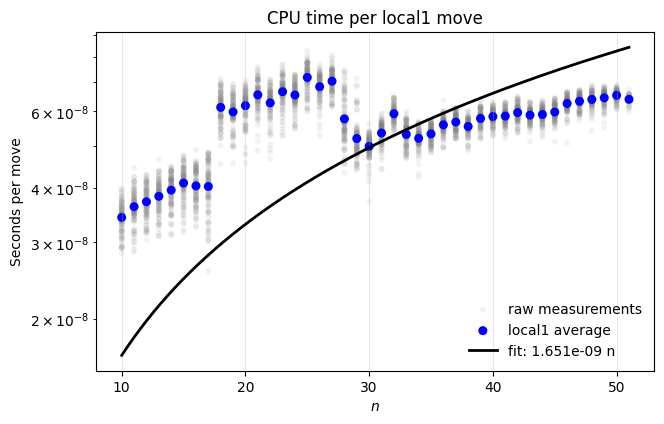

In [16]:
plot_average_cpu_time_per_n("local1")

(<Figure size 720x440 with 1 Axes>,
 <Axes: title={'center': 'CPU time per uniform move'}, xlabel='$n$', ylabel='Seconds per move'>)

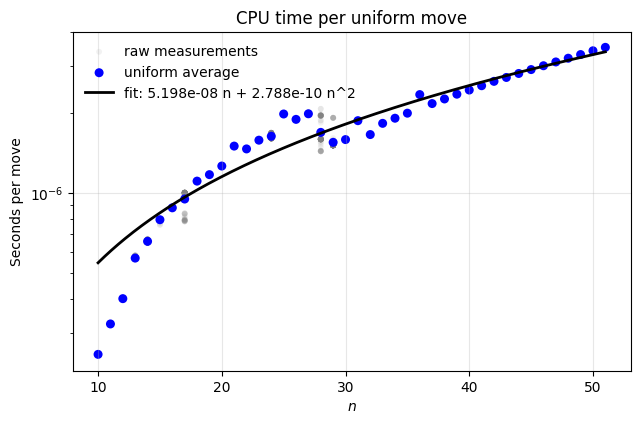

In [17]:
plot_average_cpu_time_per_n("uniform")

## Quantum time per step

In [36]:
import matplotlib.pyplot as plt
from pathlib import Path

from monaqa2.data.filename import MONAQA2_PARENT, QUANTUM_RUNTIME_ACCEPT_PATH, QUANTUM_RUNTIME_PROPOSAL_LOCAL, QUANTUM_RUNTIME_PROPOSAL_UNIFORM, QUANTUM_RUNTIME_REFLECTION
from monaqa2.data.instances import load_instances
from monaqa2.mcmc.model import IsingModel
from monaqa2.qiskit.accept_path_gate import AcceptPath
from monaqa2.qiskit.metropolis_hastings_energy_gate import MetropolisHastingsEnergy
from monaqa2.qiskit.proposal_local_gate import ProposalLocal
from monaqa2.qiskit.proposal_qemc_gate import ProposalQemc
from monaqa2.qiskit.proposal_uniform_gate import ProposalUniform
from monaqa2.qiskit.reflection_gate import Reflection
from monaqa2.qiskit.sqrt_exp_arithmetic_gate import SqrtExpArithmetic
from monaqa2.qiskit.utils_qiskit import get_nc_depth, get_rz_count, get_t_count, get_toffoli_count, qiskit_to_clifford_rz
from qiskit.circuit import Gate, QuantumCircuit
import numpy as np
import pandas as pd


def plot_single_step_quantum_nc_depth_vs_n(
    beta: float = 1.0,
    eps_2_minus: int = 16,
    statistic: str = "mean",
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    assert statistic in ["mean", "median"]

    beta = float(beta)
    eps_2_minus = int(eps_2_minus)
    beta_tag = str(beta).replace(".", "p").replace("-", "m")

    files = {
        "proposal_uniform": QUANTUM_RUNTIME_PROPOSAL_UNIFORM,
        "proposal_local1": QUANTUM_RUNTIME_PROPOSAL_LOCAL,
        "proposal_qemc": MONAQA2_PARENT / f"data/quantum_runtime_proposal_qemc_eps2minus{eps_2_minus}.pkl",
        "reflection": QUANTUM_RUNTIME_REFLECTION,
        "accept_path": QUANTUM_RUNTIME_ACCEPT_PATH,
        "coin_energy": MONAQA2_PARENT / f"data/quantum_runtime_coin_beta{beta_tag}_eps2minus{eps_2_minus}.pkl",
        "coin_sqrt_exp": MONAQA2_PARENT / f"data/quantum_runtime_coin_beta{beta_tag}_eps2minus{eps_2_minus}.pkl",
    }

    labels = {
        "proposal_uniform": "uniform proposal",
        "proposal_local1": "local proposal",
        "proposal_qemc": "QEMC proposal",
        "reflection": "reflection",
        "accept_path": "accept path",
        "coin_energy": "coin energy",
        "coin_sqrt_exp": "coin sqrt-exp",
    }

    colors = {
        "proposal_uniform": "#7A7A7A",
        "proposal_local1": "#56B4E9",
        "proposal_qemc": "#E69F00",
        "reflection": "#009E73",
        "accept_path": "#0072B2",
        "coin_energy": "#D55E00",
        "coin_sqrt_exp": "#CC79A7",
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(8.2, 4.8))
    else:
        fig = ax.figure

    for component, file in files.items():
        if not file.exists():
            continue

        df = pd.read_pickle(file)
        df = df[(df["component"] == component) & df["ok"].astype(bool)].copy()

        if component.startswith("coin"):
            df = df[np.isclose(df["beta"].astype(float), beta) & (df["eps_2_minus"].astype(int) == eps_2_minus)]

        if component == "proposal_qemc":
            df = df[df["eps_2_minus"].astype(int) == eps_2_minus]

        if component in ["reflection", "accept_path"]:
            df["x"] = df["n_plus_c"].astype(float)
        else:
            df["x"] = df["n"].astype(float)

        df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
        df = df[np.isfinite(df["x"]) & np.isfinite(df["depth"]) & (df["x"] > 0.0) & (df["depth"] > 0.0)]

        if df.empty:
            continue

        if statistic == "mean":
            table = df.groupby("x", as_index=False)["depth"].mean()
        else:
            table = df.groupby("x", as_index=False)["depth"].median()

        x = table["x"].to_numpy(dtype=float)
        y = table["depth"].to_numpy(dtype=float)

        if len(x) < 2:
            continue

        x_grid = np.linspace(float(np.min(x)), float(np.max(x)), 300)

        if component in ["proposal_qemc", "coin_sqrt_exp"]:
            b, a = np.polyfit(x, y, deg=1)
            y_fit = a + b * x_grid
            fit_label = f"{labels[component]}: {a:.3g} + {b:.3g} n"
        else:
            b, a = np.polyfit(np.log(x), y, deg=1)
            y_fit = a + b * np.log(x_grid)
            fit_label = f"{labels[component]}: {a:.3g} + {b:.3g} log(n)"
        
        ax.scatter(x, y, s=28, color=colors[component], edgecolors="none", alpha=0.90)
        ax.plot(x_grid, y_fit, color=colors[component], linewidth=2.0, label=fit_label)
        
    ax.set_xlim(4, 9)
    ax.set_xlabel(r"$n$")
    ax.set_ylabel("Non-Clifford depth")
    ax.set_title(f"Single-step quantum components, beta={beta}, eps=2^-{eps_2_minus}")
    ax.grid(True, which="major", alpha=0.30)
    ax.grid(False, which="minor")
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

    return fig, ax

(<Figure size 820x480 with 1 Axes>,
 <Axes: title={'center': 'Single-step quantum components, beta=4.0, eps=2^-2'}, xlabel='$n$', ylabel='Non-Clifford depth'>)

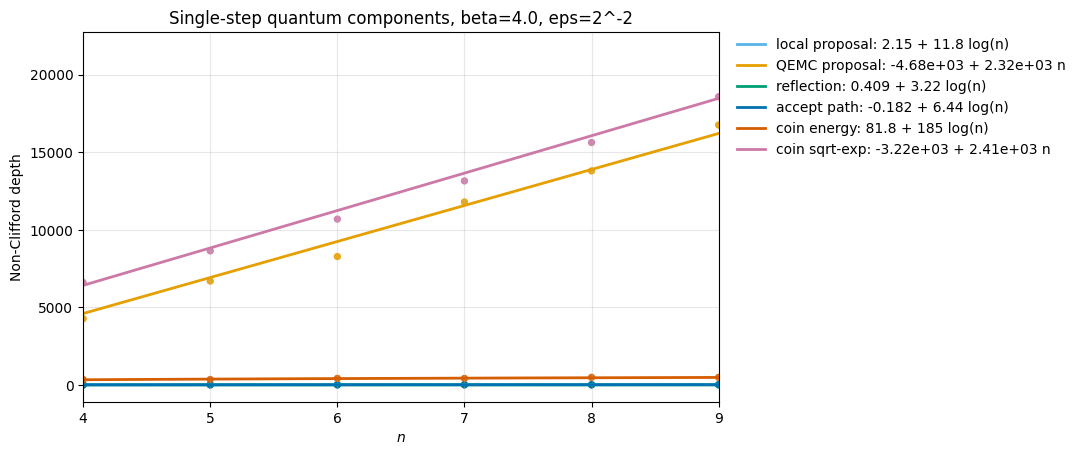

In [41]:
plot_single_step_quantum_nc_depth_vs_n(beta=4.0, eps_2_minus=2)

(<Figure size 820x480 with 1 Axes>,
 <Axes: title={'center': 'Single-step quantum components, beta=4.0, eps=2^-96'}, xlabel='$n$', ylabel='Non-Clifford depth'>)

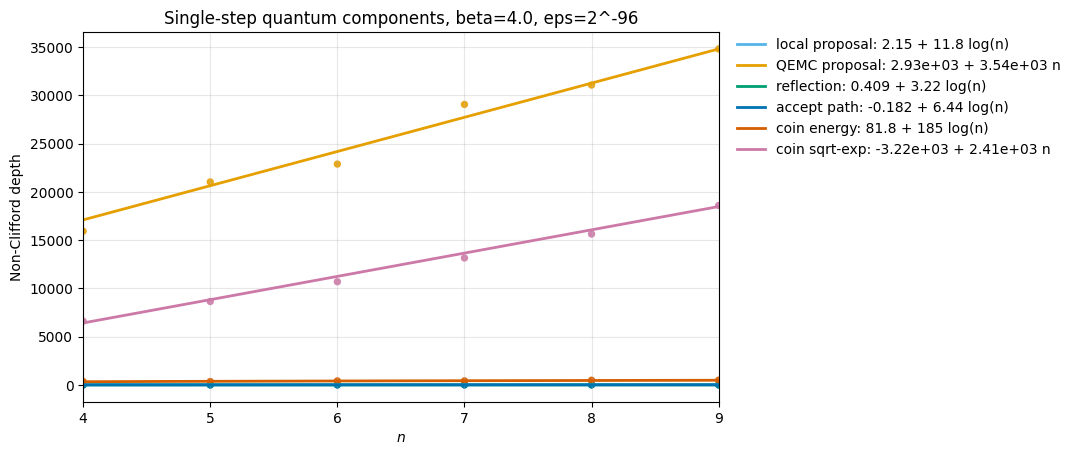

In [43]:
plot_single_step_quantum_nc_depth_vs_n(beta=4.0, eps_2_minus=96)

In [61]:
from pathlib import Path
from monaqa2.data.filename import MONAQA2_PARENT
import pandas as pd

df2 = pd.read_pickle(MONAQA2_PARENT / "data/quantum_runtime_proposal_qemc_eps2minus2.pkl")
df96 = pd.read_pickle(MONAQA2_PARENT / "data/quantum_runtime_proposal_qemc_eps2minus96.pkl")

In [64]:
df2[df2['n'] == 8]

,component,n,idx,n_plus_c,beta,eps_2_minus,eps,n_qubits,depth,t_count,ccx_count,rz_count,ok,error_message
500,proposal_qemc,8,0,NaN,NaN,2,0.25,205,13782,0,87724,27511,True,
501,proposal_qemc,8,1,NaN,NaN,2,0.25,205,13782,0,87724,27667,True,
502,proposal_qemc,8,2,NaN,NaN,2,0.25,205,14312,0,91098,28461,True,
503,proposal_qemc,8,3,NaN,NaN,2,0.25,205,14047,0,89411,28040,True,
504,proposal_qemc,8,4,NaN,NaN,2,0.25,205,14312,0,91098,28677,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,proposal_qemc,8,95,NaN,NaN,2,0.25,205,14047,0,89411,28093,True,
596,proposal_qemc,8,96,NaN,NaN,2,0.25,205,14312,0,91098,28407,True,
597,proposal_qemc,8,97,NaN,NaN,2,0.25,205,13517,0,86037,26880,True,
598,proposal_qemc,8,98,NaN,NaN,2,0.25,205,13517,0,86037,26880,True,


In [65]:
df96[df96['n'] == 8]

,component,n,idx,n_plus_c,beta,eps_2_minus,eps,n_qubits,depth,t_count,ccx_count,rz_count,ok,error_message
500,proposal_qemc,8,0,NaN,NaN,96,0.0,205,31007,0,197379,61896,True,
501,proposal_qemc,8,1,NaN,NaN,96,0.0,205,31272,0,199066,62779,True,
502,proposal_qemc,8,2,NaN,NaN,96,0.0,205,31537,0,200753,62716,True,
503,proposal_qemc,8,3,NaN,NaN,96,0.0,205,31272,0,199066,62425,True,
504,proposal_qemc,8,4,NaN,NaN,96,0.0,205,31537,0,200753,63192,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,proposal_qemc,8,95,NaN,NaN,96,0.0,205,31272,0,199066,62543,True,
596,proposal_qemc,8,96,NaN,NaN,96,0.0,205,31802,0,202440,63123,True,
597,proposal_qemc,8,97,NaN,NaN,96,0.0,205,30742,0,195692,61135,True,
598,proposal_qemc,8,98,NaN,NaN,96,0.0,205,30742,0,195692,61135,True,


In [55]:
from monaqa2.data.instances import load_instances
from monaqa2.qiskit.metropolis_hastings_energy_gate import MetropolisHastingsEnergy
from monaqa2.data.single_step_quantum import get_info, generate_coin

In [ ]:
model = load_instances(10, 0)
gate = MetropolisHastingsEnergy(10, model.h_rescaled, model.J_rescaled, 1e-2)
info = get_info(gate)
info

In [54]:
gate = MetropolisHastingsEnergy(10, model.h_rescaled, model.J_rescaled, 1e-10)
info = get_info(gate)
info

{'n_qubits': 82046,
 'depth': 661,
 't_count': 0,
 'ccx_count': 920942,
 'rz_count': 0}

In [57]:
generate_coin(10, 0, model, 1.0, 1e-2)

({'n_qubits': 29391,
  'depth': 577,
  't_count': 0,
  'ccx_count': 299807,
  'rz_count': 0},
 {'n_qubits': 169,
  'depth': 7030,
  't_count': 0,
  'ccx_count': 31251,
  'rz_count': 13401})

In [58]:
generate_coin(10, 99, model, 1.0, 1e-10)

({'n_qubits': 84178,
  'depth': 661,
  't_count': 0,
  'ccx_count': 947224,
  'rz_count': 0},
 {'n_qubits': 275,
  'depth': 10864,
  't_count': 0,
  'ccx_count': 48297,
  'rz_count': 20709})

## Classical monte carlo vs quantum walk simulations _for a warm-started, single annealing step_ (in wallclock time)


(<Figure size 850x480 with 1 Axes>,
 <Axes: title={'center': 'Classical and logical-quantum runtime, beta=4.0, a=inf, q0=bhattacharyya, epsilon=0.01, Trotter=50'}, xlabel='$n$', ylabel='Runtime [s]'>)

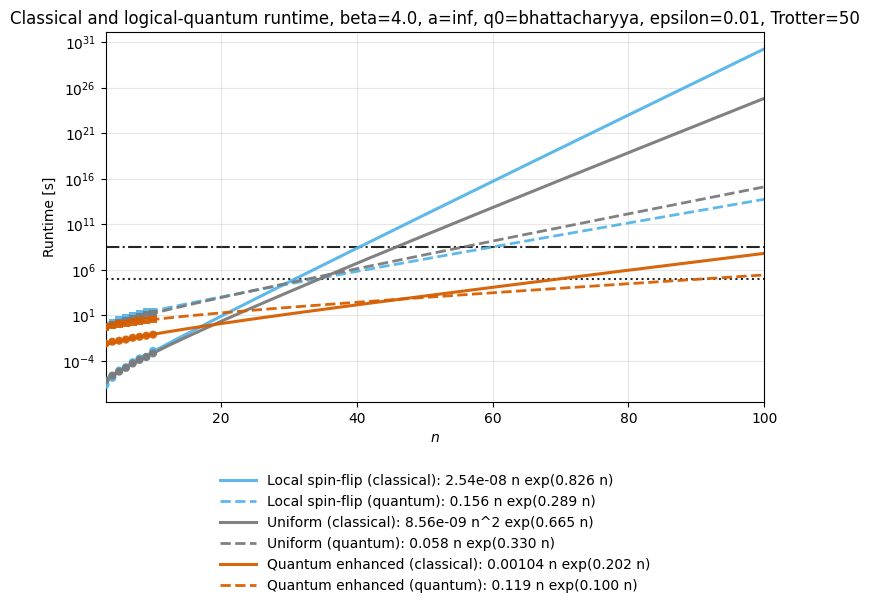

In [7]:
from monaqa2.data.plot_classical_logicalquantum_runtime_vs_n_quantum_walks_distance5 import plot_classical_logicalquantum_runtime_vs_n

plot_classical_logicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=50,
    logical_operation_time=1e-6,
    statistic="median+mad",
)

(<Figure size 850x480 with 1 Axes>,
 <Axes: title={'center': 'Classical and logical-quantum runtime, beta=4.0, a=inf, q0=bhattacharyya, epsilon=0.01, Trotter=50'}, xlabel='$n$', ylabel='Runtime [s]'>)

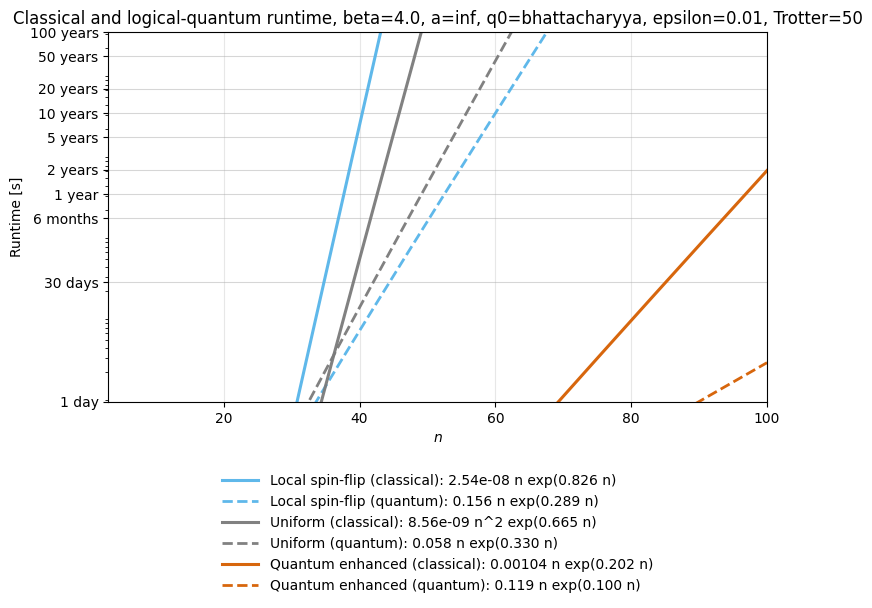

In [8]:
plot_classical_logicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=50,
    logical_operation_time=1e-6,
    statistic="median+mad",
    zoom_interesting_time=True
)

Processing quantum local1
	Fitting 31.394389958792114 * np.exp(0.28877751936386364 n)
	num_queries=np.float64(109219545312954.7)
	steps=5.293770461647391e+19
	dist=24.0
	cycle_time=4.166666666666666e-08
	physical_operation_time=2.976190476190476e-09
Processing quantum uniform
	Fitting 11.679003302623089 * np.exp(0.33008611914891794 n)
	num_queries=np.float64(2528504850989133.5)
	steps=1.2251397657893132e+21
	dist=25.0
	cycle_time=4e-08
	physical_operation_time=2.857142857142857e-09
Processing quantum layden
	Fitting 23.439255997029775 * np.exp(0.09994004723733069 n)
	num_queries=np.float64(513197.9654090145)
	steps=253896144819.08328
	dist=16.0
	cycle_time=6.25e-08
	physical_operation_time=4.464285714285714e-09
Processing classical layden
	Fitting 16.209614601185656 * np.exp(0.20197374878381016 n)
	num_queries=np.float64(9580344977.629988)
	steps=np.int64(5100)
	dist=8.0
	cycle_time=1.25e-07
	physical_operation_time=8.928571428571428e-09


(<Figure size 850x480 with 2 Axes>,
 <Axes: title={'center': 'Required surface-code distance, beta=4.0, q0=bhattacharyya, target_eps=0.33, p_phys=0.0001'}, xlabel='$n$', ylabel='Required code distance d'>)

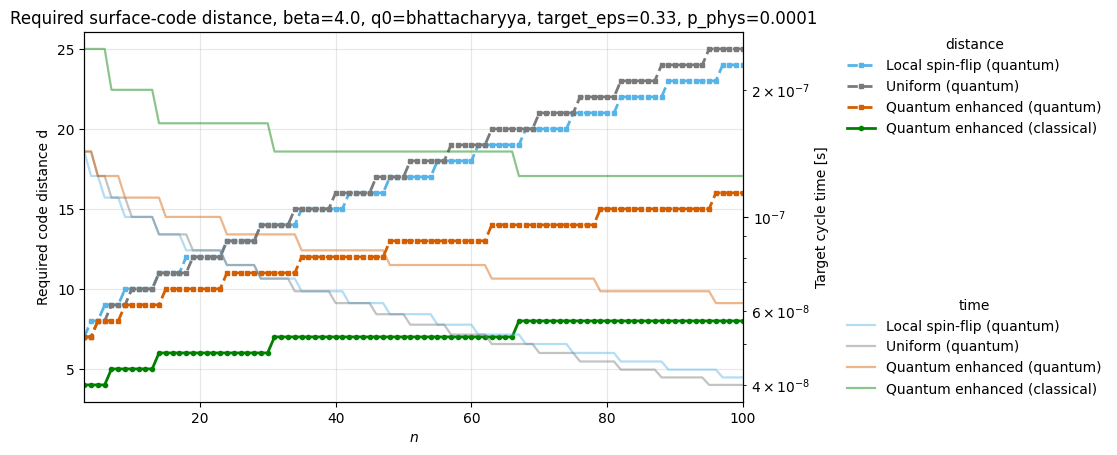

In [4]:
from monaqa2.data.plot_classical_logicalquantum_runtime_vs_n_quantum_walks_distance4 import plot_required_surface_code_distance_vs_n

plot_required_surface_code_distance_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=50,
    prob_phys_error=1e-4,
    target_eps=0.33,
    statistic="median+mad",
)

### PHYSICAL 

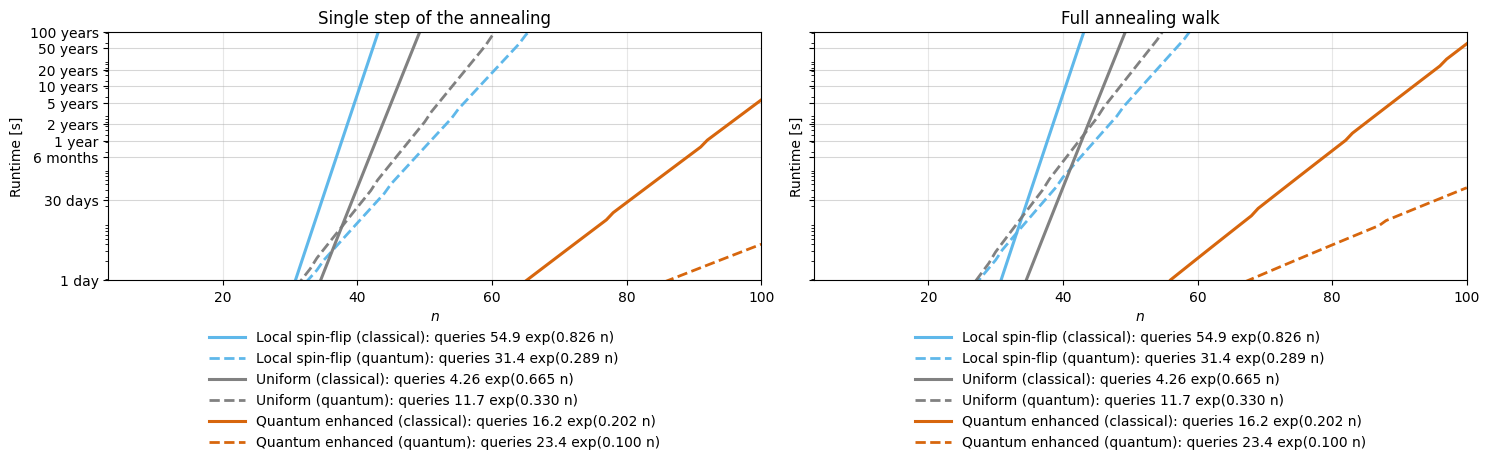

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from monaqa2.data.plot_classical_logicalquantum_runtime_vs_n_quantum_walks_distance6 import (
    plot_classical_physicalquantum_runtime_vs_n,
)


fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

plot_classical_physicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=100,
    prob_phys_error=1e-5,
    target_eps=1e-2,
    physical_operation_time=1e-8,
    annealing_overhead=False,
    statistic="median+mad",
    min_count=1,
    n_fit_min=5,
    n_fit_max=10,
    zoom_interesting_time=True,
    ax=axs[0],
)

plot_classical_physicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=100,
    prob_phys_error=1e-5,
    target_eps=1e-2,
    physical_operation_time=1e-8,
    annealing_overhead=True,
    statistic="median+mad",
    min_count=1,
    n_fit_min=5,
    n_fit_max=10,
    zoom_interesting_time=True,
    ax=axs[1],
)

axs[0].set_title("Single step of the annealing")
axs[1].set_title("Full annealing walk")

plt.tight_layout()
plt.show()

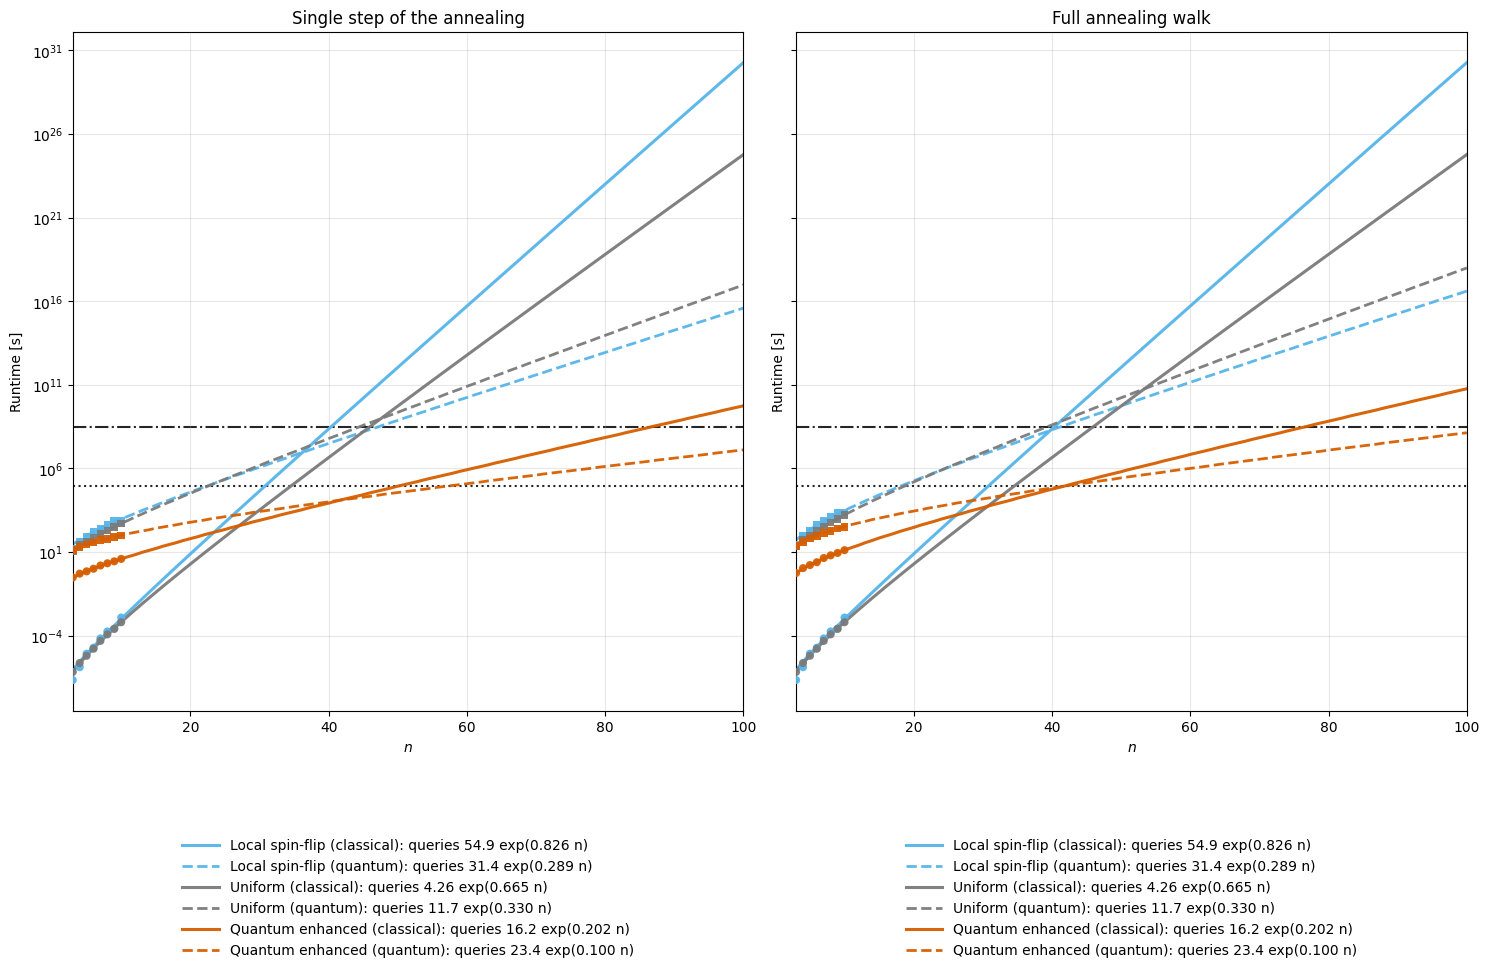

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from monaqa2.data.plot_classical_logicalquantum_runtime_vs_n_quantum_walks_distance6 import (
    plot_classical_physicalquantum_runtime_vs_n,
)


fig, axs = plt.subplots(1, 2, figsize=(15, 10), sharey=True)

plot_classical_physicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=100,
    prob_phys_error=1e-3,
    target_eps=1e-2,
    physical_operation_time=1e-7,
    annealing_overhead=False,
    statistic="median+mad",
    min_count=1,
    n_fit_min=5,
    n_fit_max=10,
    zoom_interesting_time=False,
    ax=axs[0],
)

plot_classical_physicalquantum_runtime_vs_n(
    beta=4.0,
    a=np.inf,
    q0_mode="bhattacharyya",
    epsilon=1e-2,
    num_trotter_steps=100,
    prob_phys_error=1e-3,
    target_eps=1e-2,
    physical_operation_time=1e-7,
    annealing_overhead=True,
    statistic="median+mad",
    min_count=1,
    n_fit_min=5,
    n_fit_max=10,
    zoom_interesting_time=False,
    ax=axs[1],
)

axs[0].set_title("Single step of the annealing")
axs[1].set_title("Full annealing walk")

plt.tight_layout()
plt.show()